Given $Eu$ has no net electronic spin we have a slightly different spin Hamiltonian
$$H = \underbrace{\mu_{n}\times B\times g_{n}\times I}_{\textrm{Nuclear Zeeman}}+\underbrace{I\times Q\times I}_{Quadrupole}$$

As per [Longdell et. al.](10.1103/PhysRevB.74.195101). This work focuses on ${}^{151}Eu$, with $\frac{5}{2}$ nuclear spin, that sits in a $C_{1}$ symmetry site. Note the work uses $B\times M\times I$ for its nuclear zeeman terms so we will divide M by the nuclear magneton.

In [10]:
import numpy as np
import spin_hamiltonian as spin
from scipy.spatial.transform import Rotation
import matplotlib.pyplot as plt
import matplotlib.colors as clr
from copy import deepcopy

In [11]:
#spin Operators of Eu:YSO:
Espin = 0#1/2
Ispin = 5/2

muNf = 7.622593285 #MHz/T
#muNf*=(1E6/1E4)*1E-3 #kHz/G

#Initialise the class with its electronic and nuclear spin, for both ground and excited state
ground = spin.cSpinHamiltonian(Espin,Ispin)

print(ground.I.shape)
print(ground.Idim,ground.Edim,ground.dim)
print(muNf)

(36, 3)
6 1 6
7.622593285


In [12]:
#M tensor ground state
M = np.matrix(np.diag([0.443,0.5682,1.1193]))*10/muNf#*muNf#*1E-4#/muNf#*1E-1#*spin.h*spin.muN
#Q tensor ground state
Q = -1*np.matrix(np.diag([-2.735,2.735,12.3797]))*1E6*spin.h #MHz*h

print(Q/(1E6*spin.h))

#rotated tensors
M_rot = np.array([144.9,34.9,98.1])*np.pi/180
Q_rot = np.array([-39.3,76.49,149.9])*np.pi/180

M_G = spin.tensorRotation(M,M_rot,str='ZYZ')
Q_G = spin.tensorRotation(Q,Q_rot,str='ZYZ')

print('Q',Q_G/(1E6*spin.h))
print('M',M_G)
#Initialise the static quadrapole interaction
ground.quadrupoleInteraction(Q_G)
ground.setgN(M_G)
#print(ground.H.shape)

[[  2.735    0.       0.    ]
 [  0.      -2.735    0.    ]
 [  0.       0.     -12.3797]]
Q [[-8.05309891  4.92442566 -0.95337412]
 [ 4.92442566 -4.93600935  3.76242426]
 [-0.95337412  3.76242426  0.60940826]]
M [[ 0.86681904 -0.17967655 -0.27127711]
 [-0.17967655  0.69749996  0.20667946]
 [-0.27127711  0.20667946  1.23066155]]


# ZEFOZ notes:
Critical points occur when:
$$\frac{\partial f_{nm}}{\partial B_{i}} = \left<\psi_{n}\right|A_{i}\left|\psi_{m}\right>=0$$

Our sensitivity is the extension:
$$\vec{S}_{1} = \frac{\partial f_{nm}}{\partial B_{x}}\vec{i}+\frac{\partial f_{nm}}{\partial B_{y}}\vec{j}+\frac{\partial f_{nm}}{\partial B_{z}}\vec{k}$$

Maximum curvature given by the largest eigenvalue of $S_{2}$
$$\vec{S}_{2} = \begin{pmatrix}\frac{\partial^2 f}{\partial B_{x}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{x}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{y}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{y}\partial B_{z}}\\\frac{\partial^2 f}{\partial B_{z}\partial B_{x}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{y}}&\frac{\partial^2 f}{\partial B_{z}\partial B_{z}}\end{pmatrix}$$

Where
$$\frac{\partial^2 f}{\partial B_{i}\partial B_{j}} =\sum_{m\neq n}\frac{1}{f_{n}-f_{m}}\left[\left<\psi_{m}\right|A_{i}\left|\psi_{n}\right>\left<\psi_{n}\right|A_{j}\left|\psi_{m}\right>+c.c.\right]+G_{i,j}+G_{j,i} $$

This gives our $T_{2}$ time at a ZEFOZ point:
$$\frac{1}{\pi T_{2}} = \vec{S}_{1}\cdot\Delta\vec{B}+\Delta\vec{B}\cdot\vec{S}_{2}\cdot\Delta\vec{B}$$

In [13]:

#
Is = spin.spinOperator(Ispin,matricies=True)
As = spin.genAMatrix(spin.muN*M_G,Is)

def singleLoop(X,Y,Z):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    
    Fp = []
    #OS = np.zeros((ground.dim,3),dtype = np.csingle)
    for l in range(3):
        v = ground.firstOrderEnergySensitivity(VG,As[l]/spin.muN)*spin.muN
        Fp.append(v)
    Fp = np.array(Fp).T
    Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG)#*spin.muN
    Fpp = 1
    return (F,Fp,Fpp)


#our loop
def sweep(Bx,By,Bz):
    #sets the default dynamic term as both electronic and nuclear zeeman
    F = ground.initSweep(Bx,By,Bz)
    Fp = np.zeros((len(Bx),len(By),len(Bz),ground.dim,3),dtype = np.csingle)#
    Fpp = ground.initSweep(Bx,By,Bz,ground.dim)

    for i in range(len(Bx)):
        for j in range(len(By)):
            for k in range(len(Bz)):
                F[i,j,k,:],Fp[i,j,k,:],Fpp[i,j,k,:] = singleLoop(Bx[i],By[j],Bz[k])
    #return all transion based values         
    return spin.eachElemFunc(F,F,ax=3),spin.eachElemFunc(Fp,Fp,ax=3),spin.eachElemFunc(Fpp,Fpp,ax=3)


def initGradDescent(X,Y,Z):
    #convert spherical Magnetic field to cartesian coords.
    B = np.matrix([X,Y,Z]).T
    
    #Calculate our hamiltonian at this B Field
    HG = ground.H+ground.nuclearZeeman(B)#/spin.muN

    #get the eigen frequencies and vectors at this B field
    FG,VG = ground.getEigFreq(HG)
    F=FG*1E3
    Fpp = ground.curvatureCalculation(As[0],As[1],As[2],VG,FG)#*spin.muN
    return (F,Fpp)


In [14]:
pts =10

np.set_printoptions(threshold=np.inf)

Bxi = np.linspace(-10,10,pts)
Byi = Bxi
Bzi = Bxi

delta = (Bxi[-1]-Bxi[0])/len(Bxi)


Fi,Fip,Fipp=sweep(Bxi,Byi,Bzi)
Idi = spin.ZEFOZidx(Fip)
Idu = np.unique(Idi[:,0:3],axis=0)
print("Initial Run Found: "+str(Idi.shape[0])+" Points at "+str(Idu.shape[0])+" Magnetic field orientations")



Initial Run Found: 532 Points at 167 Magnetic field orientations


In [15]:
print(Fip[-10,-10,-10,0,:])


# x,y,z = np.meshgrid(Bxi,Byi,Bzi)
# np.vectorize(singleLoop)(x,y,z)
# ret = np.frompyfunc(singleLoop,3,3)(x,y,z)
# print(ret.shape)

[0.+0.j 0.+0.j 0.+0.j]


[[ 8  7  6 22]
 [ 8  7  6 27]
 [ 8  8  5 22]
 [ 8  8  5 27]] [-8.22222222 -8.22222222 -8.22222222 -8.22222222]


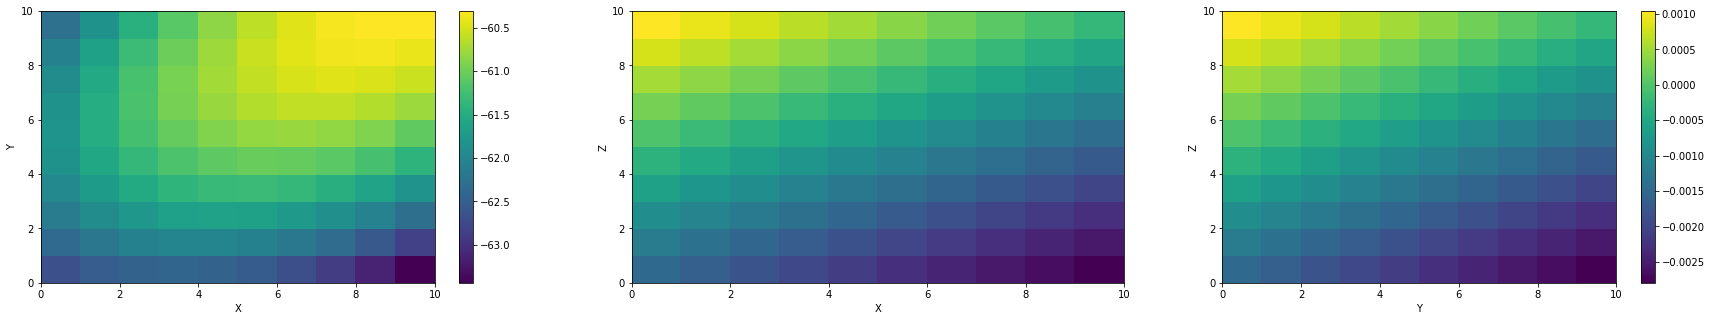

1


In [16]:

Fs = []
Fps=[]
Fpps=[]
##ids=[]
Bs = []

fig = plt.figure(figsize=(30,5))

for i in Idu:
    #print(i)
    Bx = np.linspace(Bxi[i[0]],Bxi[i[0]]+delta,pts)
    By = np.linspace(Byi[i[1]],Byi[i[1]]+delta,pts)
    Bz = np.linspace(Bzi[i[2]],Bzi[i[2]]+delta,pts)
    #print(Bx)
    F,Fp,Fpp = sweep(Bx,By,Bz)
        
    id = spin.ZEFOZidx(Fp)
    #print(F.shape,print(tid))
    #print(id)
    if id.size>0:
        tid= tuple(id.T)
        print(id,Bx[id[:,0]])
        zx = spin.zero_crossings(Fp,ax=3)
        #print(zx)
        #print(zx[7,2,7,:,:])

        Fs.append(F[tid])
        Fps.append(Fp[tid])
        Fpps.append(Fpp[tid])
        Bs.append([Bx[id[:,0]],By[id[:,1]],Bz[id[:,2]]])
        #plt.plot(np.real(Fp[:,7,0,29,0]),'r*-')
        #plt.plot(np.real(Fp[8,:,0,29,1]),'g*-')
        #plt.plot(np.real(Fp[8,7,:,29,2]),'b*-')
        #plt.plot(np.zeros(Fp.shape[0]))
        ax = plt.subplot(1,3,1)
        plt.pcolor(np.real(F[:,:,6,22]))
        plt.xlabel("X")
        plt.ylabel("Y")
        plt.colorbar()

        ax = plt.subplot(1,3,2)
        plt.pcolor(np.real(Fp[:,:,6,22,0]))
        plt.xlabel("X")
        plt.ylabel("Z") 
        ax = plt.subplot(1,3,3)
        plt.pcolor(np.real(Fp[:,:,6,22,0]))
        plt.xlabel("Y")
        plt.ylabel("Z")

        #plt.ylim([-0.005,0.005])
        plt.colorbar()

        plt.show()
        plt.close()
        break

    #print(Bs)

print(len(Fs))

In [17]:
print(np.concatenate(Fpps).shape)
print(Fpps)
#print(Bs)
#print(Idi)
#print(Idi[:,0:3])


(4,)
[array([0.+0.j, 0.+0.j, 0.+0.j, 0.+0.j], dtype=complex64)]


In [18]:
OS = spin.eachElemFunc(OS_SG,OS_SG,ax=3)
CS = np.abs(spin.eachElemFunc(CS_G,CS_G,ax=3))

#np.savez("1E-1_linear_grid",FG,OS_SG,CS_G)
ps = spin.zero_crossings(OS,2)
print(ps.shape)
id = spin.ZEFOZidx(OS,2)

print(id.shape)
print(id[0])
u,c = np.unique(id[:,3],return_counts=True)

print(u,c)
print((Bs[-1]-Bs[0])/len(Bs))


B = np.sqrt(Bs[id[:,0]]**2+Bs[id[:,1]]**2+Bs[id[:,2]]**2)

C = np.array([1.77,-0.63,-0.45])
Cn =np.linalg.norm(C)*1E4
print(Cn)

plt.loglog(CS[tuple(id.T)]*1E1,B*1E4,'+')
plt.loglog(np.logspace(-2,6,10),Cn*np.ones(10),'r--')
plt.ylabel(r'$Field(G)$')
plt.xlabel(r"$\frac{\partial^2f}{\partial B^{2}}(Hz/G^2)$")
plt.xlim([1E-2,1E6])
plt.ylim([1E2,1E6])
plt.xticks([1E-2,1E0,1E2,1E4,1E6])
plt.grid()
plt.show()
plt.close()




NameError: name 'OS_SG' is not defined